In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

In [2]:
def load_all_WESAD_data(base_path='data/WESAD'):
    """
    Scans the WESAD directory, loads all available subject .pkl files,
    and returns a dictionary containing raw sensor data for each subject.
    """
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Base dataset path not found: {base_path}")

    all_subjects_data = {}
    
    # WESAD subjects are typically S2-S17 (S1 and S12 are missing by default)
    # Dynamically find all folders starting with 'S'
    subject_folders = [f for f in os.listdir(base_path) if f.startswith('S') and os.path.isdir(os.path.join(base_path, f))]
    
    # Sort them numerically so they process in order (S2, S3, S4...)
    subject_folders.sort(key=lambda x: int(x[1:]))

    print(f"Found {len(subject_folders)} subjects: {subject_folders}\n")

    for subject_ID in subject_folders:
        path = os.path.join(base_path, subject_ID, f'{subject_ID}.pkl')
        
        if not os.path.exists(path):
            print(f"Warning: Data file missing for {subject_ID} at {path}. Skipping.")
            continue
            
        print(f"Loading data for {subject_ID}...")
        with open(path, 'rb') as file:
            data = pickle.load(file, encoding='latin1')

        wrist_data = data['signal']['wrist']
        
        # Store each subject's arrays in a nested dictionary
        all_subjects_data[subject_ID] = {
            'bvp': wrist_data['BVP'],
            'acc': wrist_data['ACC'],
            'temp': wrist_data['TEMP'],
            'eda': wrist_data['EDA'],
            'labels': data['label']
        }

    print("\nAll patient data loaded successfully!")
    return all_subjects_data

Found 15 subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

Loading data for S2...
Loading data for S3...
Loading data for S4...
Loading data for S5...
Loading data for S6...
Loading data for S7...
Loading data for S8...
Loading data for S9...
Loading data for S10...
Loading data for S11...
Loading data for S13...
Loading data for S14...
Loading data for S15...
Loading data for S16...
Loading data for S17...

All patient data loaded successfully!


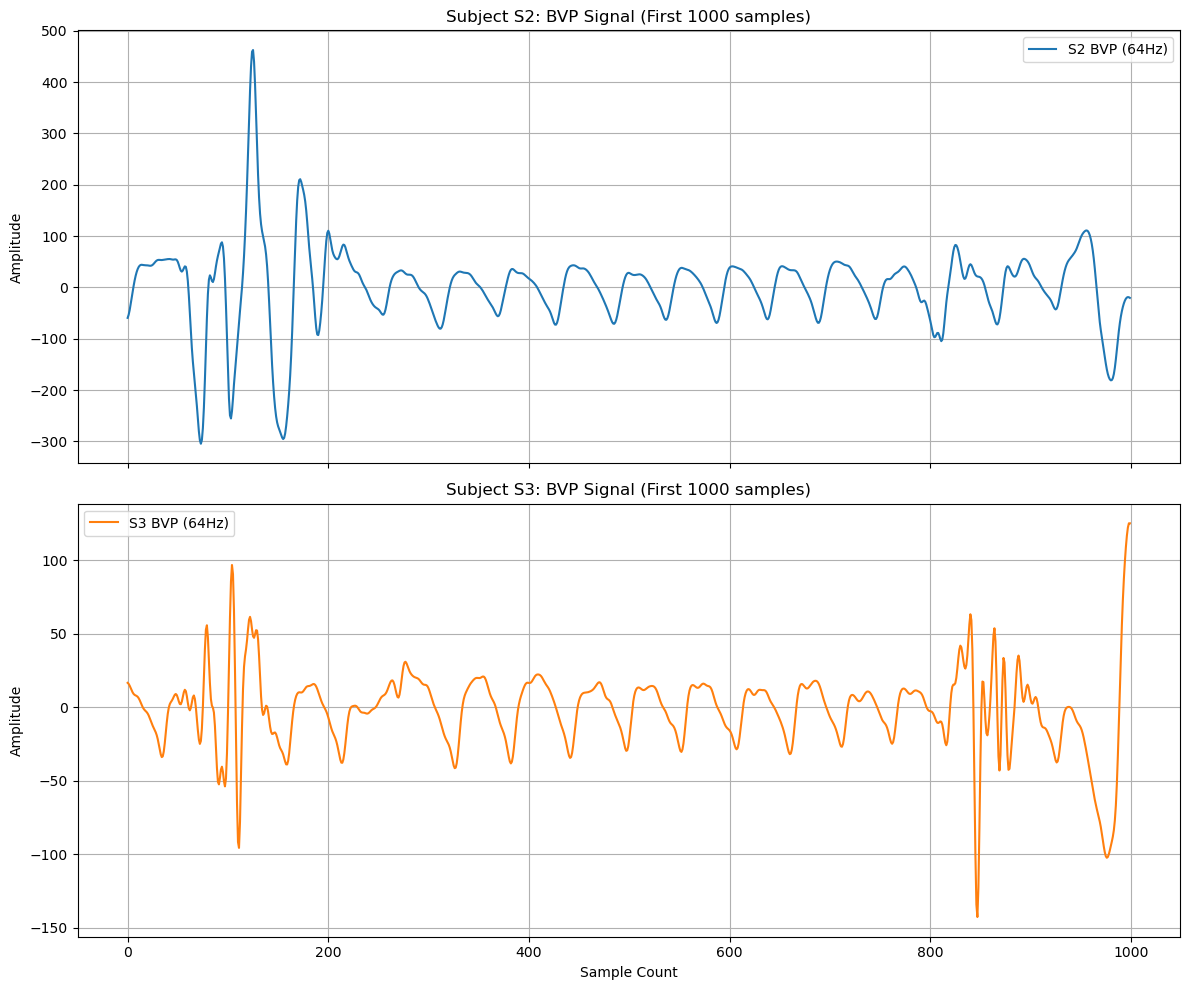

In [3]:
if __name__ == "__main__":
    # Define the base folder where all subject folders (S2, S3, etc.) live
    WESAD_BASE_PATH = 'data/WESAD'
    
    # Load everything into a single dictionary
    dataset = load_all_WESAD_data(WESAD_BASE_PATH)

    # Example: Plot the BVP signal for the first two available subjects to verify
    subjects_to_plot = list(dataset.keys())[:2] 
    
    if len(subjects_to_plot) >= 2:
        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        
        for i, subj in enumerate(subjects_to_plot):
            bvp_sample = dataset[subj]['bvp'][:1000]
            axes[i].plot(bvp_sample, label=f'{subj} BVP (64Hz)', color='C'+str(i))
            axes[i].set_title(f"Subject {subj}: BVP Signal (First 1000 samples)")
            axes[i].set_ylabel("Amplitude")
            axes[i].grid(True)
            axes[i].legend()
            
        axes[-1].set_xlabel("Sample Count")
        plt.tight_layout()
        plt.show()